<a href="https://colab.research.google.com/github/navap3206-debug/hello-world/blob/main/T02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio de regresión - 2

|                |   |
:----------------|---|
| **Nombre**     |Carlos Santiago   |
| **Fecha**      |29/01/2026   |
| **Expediente** | 756213  |

## Regresión polinomial

Observa la siguiente gráfica.

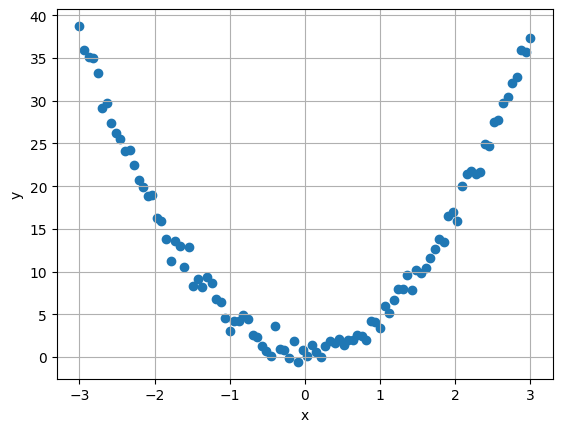

In [1]:
import matplotlib.pyplot as plt; import numpy as np
%matplotlib inline
np.random.seed(0)
x = np.linspace(-3, 3, 100); y = 1 + 4*x**2 + np.random.normal(0, 1, 100)
plt.figure(); plt.xlabel("x"); plt.ylabel("y")
plt.scatter(x, y); plt.grid()

Utiliza `sklearn` para realizar una regresión lineal simple ($\hat{y} = \hat{\beta_0} + \hat{\beta_1}x $)

In [2]:
from sklearn.linear_model import LinearRegression

In [3]:
from sklearn import linear_model
x = x.reshape(-1, 1)
y = y.reshape(-1, 1)

lr = LinearRegression(fit_intercept = True) #No consideramos la columna de Y
lr.fit(x,y) #Entrenamos


LinearRegression()

In [4]:
lr.intercept_, lr.coef_ #Imprimo los coeficientes

(array([13.30223226]), array([[-0.04955448]]))

Crea una gráfica donde se muestren las observaciones como una nube de puntos y la línea que ajustaste con regresión. Calcula el métrico $R^2$.

In [5]:
lr.score(x,y)

5.80345273922811e-05

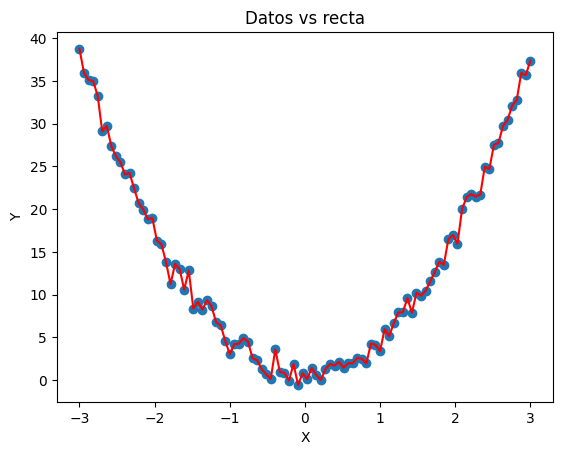

In [6]:
y_l = lr.intercept_ + lr.coef_ * x
plt.scatter(x,y)
plt.plot(x,y,color= "red")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Datos vs recta")
plt.show()



Podemos ver que el ajuste no es correcto, pues parece que tiene un comportamiento cuadrático y estamos intentando ajustar una línea recta.

En lugar de hacer una regresión lineal simple, quizás podamos extender el modelo para que tenga varios factores dentro:

$$ Y = \beta_0 + \beta_1 X + \beta_2 X^2 + ... + \beta_p X^p + \epsilon$$

Ajusta un modelo cuadrático con `sklearn` ($\hat{y} = \hat{\beta_0} + \hat{\beta_1}x + \hat{\beta_1}x^2 $) y calcula su $R^2$.

In [7]:
X_matrix = np.array([[pt[0], pt[0]**2] for pt in x])
X_matrix


array([[-3.00000000e+00,  9.00000000e+00],
       [-2.93939394e+00,  8.64003673e+00],
       [-2.87878788e+00,  8.28741965e+00],
       [-2.81818182e+00,  7.94214876e+00],
       [-2.75757576e+00,  7.60422406e+00],
       [-2.69696970e+00,  7.27364555e+00],
       [-2.63636364e+00,  6.95041322e+00],
       [-2.57575758e+00,  6.63452709e+00],
       [-2.51515152e+00,  6.32598714e+00],
       [-2.45454545e+00,  6.02479339e+00],
       [-2.39393939e+00,  5.73094582e+00],
       [-2.33333333e+00,  5.44444444e+00],
       [-2.27272727e+00,  5.16528926e+00],
       [-2.21212121e+00,  4.89348026e+00],
       [-2.15151515e+00,  4.62901745e+00],
       [-2.09090909e+00,  4.37190083e+00],
       [-2.03030303e+00,  4.12213039e+00],
       [-1.96969697e+00,  3.87970615e+00],
       [-1.90909091e+00,  3.64462810e+00],
       [-1.84848485e+00,  3.41689624e+00],
       [-1.78787879e+00,  3.19651056e+00],
       [-1.72727273e+00,  2.98347107e+00],
       [-1.66666667e+00,  2.77777778e+00],
       [-1.

In [8]:
lr = LinearRegression(fit_intercept = True)
lr.fit(X_matrix, y)
lr.score(X_matrix, y)

0.9934118040713642

In [9]:
lr.coef_, lr.intercept_

(array([[-0.04955448,  4.14388884]]), array([0.61942096]))

Crea una gráfica con las observaciones y la nueva curva que ajustaste.

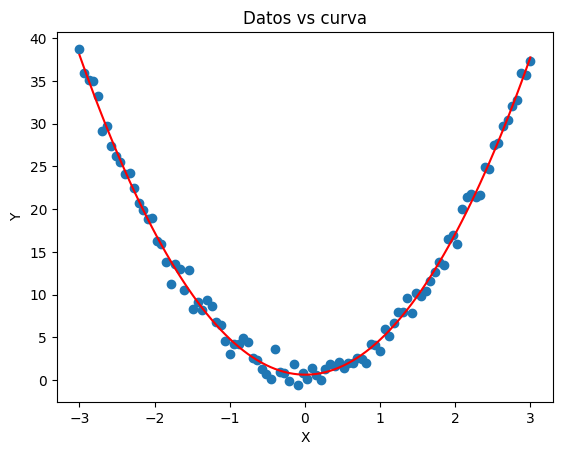

In [10]:
y_c = lr.intercept_ + lr.coef_[0][0] * x + lr.coef_[0][1] * x**2
plt.scatter(x,y)
plt.plot(x,y_c,color="red")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Datos vs curva")
plt.show()

Ajusta modelos de grados 3, 5, 7, 9, y 11. Calcula su $R^2$.

In [16]:
matrix_3 = np.array([[pt[0],pt[0]**2,pt[0]**3] for pt in x])
matrix_5 = np.array([[pt[0], pt[0]**2, pt[0]**3, pt[0]**4, pt[0]**5] for pt in x])
matrix_7 = np.array([[pt[0], pt[0]**2, pt[0]**3, pt[0]**4, pt[0]**5, pt[0]**6, pt[0]**7] for pt in x])
matrix_9 = np.array([[pt[0], pt[0]**2, pt[0]**3, pt[0]**4, pt[0]**5, pt[0]**6, pt[0]**7, pt[0]**8, pt[0]**9] for pt in x])
matrix_11 = np.array([[pt[0], pt[0]**2, pt[0]**3, pt[0]**4, pt[0]**5, pt[0]**6, pt[0]**7, pt[0]**8, pt[0]**9, pt[0]**10, pt[0]**11] for pt in x])

In [17]:
lr_3 = LinearRegression(fit_intercept = True)
lr_3.fit(matrix_3, y)
lr_5 = LinearRegression(fit_intercept = True)
lr_5.fit(matrix_5, y)
lr_7 = LinearRegression(fit_intercept = True)
lr_7.fit(matrix_7, y)
lr_9 = LinearRegression(fit_intercept = True)
lr_9.fit(matrix_9, y)
lr_11 = LinearRegression(fit_intercept = True)
lr_11.fit(matrix_11, y)

print(f'R^2_3: {lr_3.score(matrix_3, y)}')
print(f'R^2_5: {lr_5.score(matrix_5, y)}')
print(f'R^2_7: {lr_7.score(matrix_7, y)}')
print(f'R^2_9: {lr_9.score(matrix_9, y)}')
print(f'R^2_11: {lr_11.score(matrix_11, y)}')

R^2_3: 0.9934129585186598
R^2_5: 0.9934954953676421
R^2_7: 0.9935089341876935
R^2_9: 0.9935141799662259
R^2_11: 0.9935338704150221


Crea una gráfica por cada modelo con las observaciones y su curva.

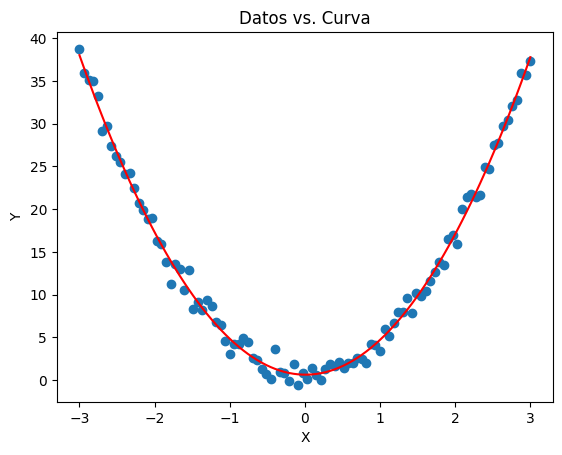

In [23]:
#Gráfica grado 3
y_pred_3 = lr_3.intercept_ + matrix_3 @ lr_3.coef_.T
plt.figure()
plt.scatter(x, y)
plt.plot(x, y_pred_3, color='red')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Datos vs. Curva')
plt.show()

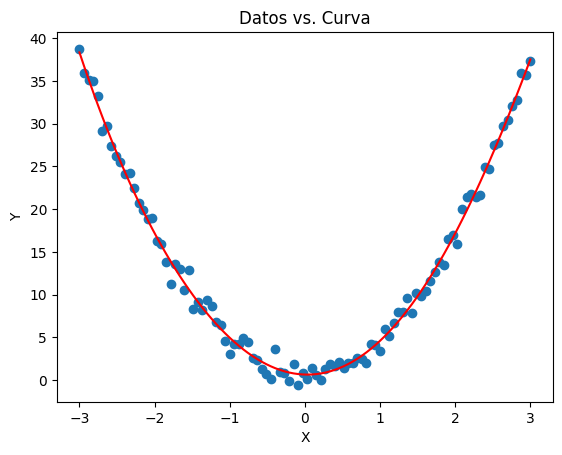

In [24]:
#Gráfica grado 3
y_pred_5 = lr_5.intercept_ + matrix_5 @ lr_5.coef_.T  #Usando producto punto con la tranpuesta de los coeficientes
plt.figure()
plt.scatter(x, y)
plt.plot(x, y_pred_5, color='red')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Datos vs. Curva')
plt.show()

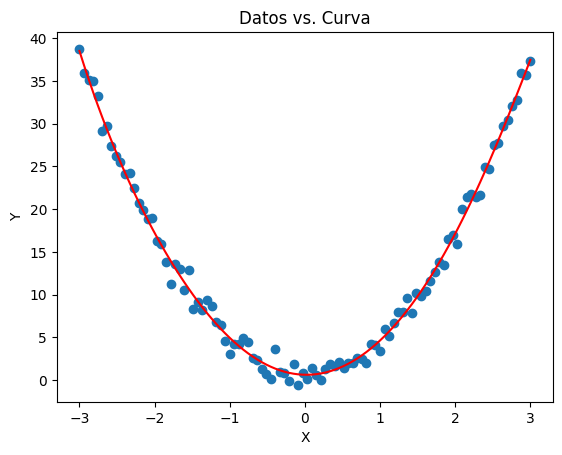

In [25]:
y_pred_7 = lr_7.intercept_ + matrix_7 @ lr_7.coef_.T  #Usando producto punto con la tranpuesta de los coeficientes
plt.figure()
plt.scatter(x, y)
plt.plot(x, y_pred_7, color='red')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Datos vs. Curva')
plt.show()

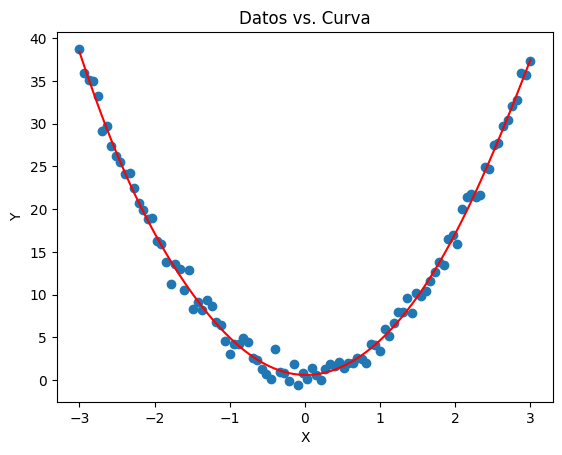

In [26]:
y_pred_9 = lr_9.intercept_ + matrix_9 @ lr_9.coef_.T  #Usando producto punto con la tranpuesta de los coeficientes
plt.figure()
plt.scatter(x, y)
plt.plot(x, y_pred_9, color='red')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Datos vs. Curva')
plt.show()

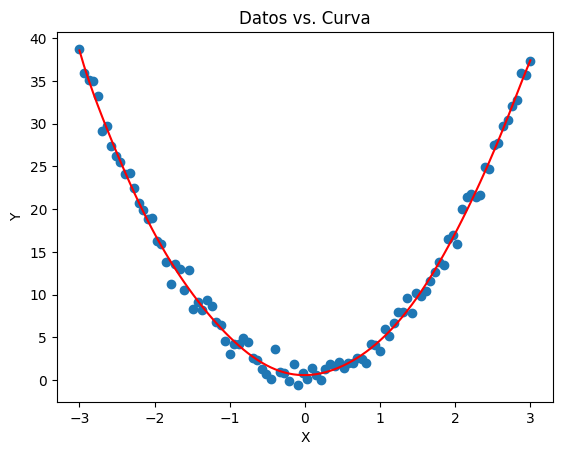

In [27]:
y_pred_11 = lr_11.intercept_ + matrix_11 @ lr_11.coef_.T  #Usando producto punto con la tranpuesta de los coeficientes
plt.figure()
plt.scatter(x, y)
plt.plot(x, y_pred_11, color='red')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Datos vs. Curva')
plt.show()

**¿Cuál modelo consideras que es mejor? ¿Por qué?**

In [28]:
#Recupero la r2
print(f'R^2_3: {lr_3.score(matrix_3, y)}')
print(f'R^2_5: {lr_5.score(matrix_5, y)}')
print(f'R^2_7: {lr_7.score(matrix_7, y)}')
print(f'R^2_9: {lr_9.score(matrix_9, y)}')
print(f'R^2_11: {lr_11.score(matrix_11, y)}')

R^2_3: 0.9934129585186598
R^2_5: 0.9934954953676421
R^2_7: 0.9935089341876935
R^2_9: 0.9935141799662259
R^2_11: 0.9935338704150221


Considerando los datos y visualizaciones obtenidas es dificil decir que realmente alguna aproxime mejor que otra. En general todas las R son cercanas a 0 aunque podríamos buscar la mas alta...

In [33]:
max(lr_3.score(matrix_3, y), lr_5.score(matrix_5, y), lr_7.score(matrix_7, y), lr_9.score(matrix_9,y), lr_11.score(matrix_11, y))

0.9935338704150221

R2 DE MATRIZ 11° grado tiene un R2 mayor al resto, sin embargo en el caso de extrapolar parecería ser un comportamiento atipico a lo esperado

Recuerda que una de las metas de ajustar modelos es para poder interpolar y extrapolar. Los datos que tenemos mantienen $x \in [-3, 3]$. ¿Qué pasaría si quisiéramos saber el valor de $y$ cuando $x=5$?

Calcula la predicción $\hat{y}$ para todos los modelos creados (grados 2, 3, 5, 7, 9, y 11).

In [38]:
#Creamos las matrices para predecir...
print( lr.predict(np.array([[5, 5**2]]))[0][0])
print( lr_3.predict(np.array([[5, 5**2, 5**3]]))[0][0])
print( lr_5.predict(np.array([[5, 5**2, 5**3, 5**4, 5**5]]))[0][0])
print( lr_7.predict(np.array([[5, 5**2, 5**3, 5**4, 5**5, 5**6, 5**7]]))[0][0])
print( lr_9.predict(np.array([[5, 5**2, 5**3, 5**4, 5**5, 5**6, 5**7, 5**8, 5**9]]))[0][0])
print( lr_11.predict(np.array([[5, 5**2, 5**3, 5**4, 5**5, 5**6, 5**7, 5**8, 5**9, 5**10, 5**11]]))[0][0])

103.9688695481995
104.25232438790744
84.59895012672999
33.743218476161
215.73637926220619
-5265.344253540989


¿Cuál modelo crees que sea mejor?

Me parece que Grado 2 debería ser el más apropiado sobre todo al extrapolar los datos, la forma de la función fuera del intervalo [3,3] parece concordar mas con las primeras dos regresiones sin embargo con rangos más amplios, grado 2 debería ser más fiel.

## Referencia

James, G., Witten, D., Hastie, T., Tibshirani, R.,, Taylor, J. (2023). An Introduction to Statistical Learning with Applications in Python. Cham: Springer. ISBN: 978-3-031-38746-3